# Task 3 — Feature Engineering
**10 Academy AI Mastery · Week 4 · Bati Bank Credit Risk Model**

This notebook covers every feature engineering step interactively.
All logic here is later promoted to `src/data_processing.py` for production use.

### Sections
1. Setup & data loading
2. Time feature extraction
3. Customer-level aggregate features
4. RFM feature construction
5. Outlier treatment — Winsorization
6. Categorical encoding
7. sklearn preprocessing pipeline (Imputer → StandardScaler)
8. Final merged dataset inspection & feature–target correlation


## 0. Setup

In [51]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath(".."))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from src.data_processing import (
    load_raw_data, extract_time_features,
    build_aggregate_features, build_rfm_features,
    winsorize_features, encode_categorical_features,
    get_preprocessing_pipeline,
)

os.makedirs("../plots/feature_engineering", exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (13, 4)})
SEED = 42
np.random.seed(SEED)
print("✅ Environment ready.")


✅ Environment ready.


## 1. Load Data

Place the Xente CSV at `data/raw/data.csv`.  
A synthetic fallback is generated automatically if the file is absent.


In [52]:
DATA_PATH = "../data/raw/data.csv"

try:
    df = load_raw_data(DATA_PATH)
    print(f"✅ Real dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
except FileNotFoundError:
    print("⚠️  Raw file not found — generating synthetic demo data.")
    np.random.seed(SEED)
    n = 95_469
    customers = [f"C{i}" for i in range(1, 3_755)]
    df = pd.DataFrame({
        "TransactionId":        [f"T{i}" for i in range(n)],
        "CustomerId":           np.random.choice(customers, n),
        "AccountId":            [f"A{np.random.randint(1,8000)}" for _ in range(n)],
        "ProductId":            [f"P{np.random.randint(1,30)}"   for _ in range(n)],
        "ProductCategory":      np.random.choice(
            ["airtime","financial_services","utility_bill","data_bundles","tv","other"],
            n, p=[0.45,0.38,0.07,0.05,0.03,0.02]),
        "ChannelId":            np.random.choice(
            ["ChannelId_1","ChannelId_2","ChannelId_3","ChannelId_4","ChannelId_5"],
            n, p=[0.01,0.39,0.55,0.03,0.02]),
        "ProviderId":           np.random.choice(
            [f"ProviderId_{i}" for i in range(1,7)], n,
            p=[0.06,0.00,0.03,0.40,0.15,0.36]),
        "TransactionStartTime": pd.date_range("2018-11-01", periods=n, freq="5min"),
        "Amount": np.where(
            np.random.rand(n) > 0.4,
            np.random.lognormal(7.5, 1.5, n),
           -np.random.lognormal(7.0, 1.2, n)),
        "Value":        np.abs(np.random.lognormal(7.5, 1.5, n)),
        "FraudResult":  np.random.choice([0,1], n, p=[0.998,0.002]),
        "PricingStrategy": np.random.choice([0,1,2,4], n, p=[0.004,0.019,0.832,0.145]),
    })
    df["Value"] = df["Amount"].abs()

df.head(3)


2026-06-02 23:22:34,397 [INFO] src.data_processing — Loading raw data from ../data/raw/data.csv
2026-06-02 23:22:35,759 [INFO] src.data_processing — Loaded 95,662 rows × 16 columns


✅ Real dataset loaded: 95,662 rows × 16 columns


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0


In [53]:
print(f"Shape       : {df.shape}")
print(f"Date range  : {df['TransactionStartTime'].min().date()} → {df['TransactionStartTime'].max().date()}")
print(f"Customers   : {df['CustomerId'].nunique():,}")
print(f"Missing vals: {df.isna().sum().sum()}")
df.dtypes


Shape       : (95662, 16)
Date range  : 2018-11-15 → 2019-02-13
Customers   : 3,742
Missing vals: 0


TransactionId                           str
BatchId                                 str
AccountId                               str
SubscriptionId                          str
CustomerId                              str
CurrencyCode                            str
CountryCode                           int64
ProviderId                              str
ProductId                               str
ProductCategory                         str
ChannelId                               str
Amount                              float64
Value                                 int64
TransactionStartTime    datetime64[us, UTC]
PricingStrategy                       int64
FraudResult                           int64
dtype: object

## 2. Time Feature Extraction

Decompose `TransactionStartTime` into five temporal features:

| Feature | Description |
|---------|-------------|
| `txn_hour` | Hour of day (0–23) |
| `txn_day` | Day of month (1–31) |
| `txn_month` | Month (1–12) |
| `txn_year` | Year |
| `txn_dayofweek` | Day of week (0=Monday, 6=Sunday) |

**Credit risk relevance:** Late-night transactions and end-of-month spikes
can signal financial stress; Friday peaks reflect payroll cycles.


In [54]:
df = extract_time_features(df)
new_cols = [c for c in df.columns if c.startswith("txn_")]
print("New columns added:", new_cols)
df[["TransactionStartTime"] + new_cols].head(5)


2026-06-02 23:22:35,988 [INFO] src.data_processing — Time features extracted: txn_hour, txn_day, txn_month, txn_year, txn_dayofweek


New columns added: ['txn_hour', 'txn_day', 'txn_month', 'txn_year', 'txn_dayofweek']


,TransactionStartTime,txn_hour,txn_day,txn_month,txn_year,txn_dayofweek
0,2018-11-15 02:18:49+00:00,2,15,11,2018,3
1,2018-11-15 02:19:08+00:00,2,15,11,2018,3
2,2018-11-15 02:44:21+00:00,2,15,11,2018,3
3,2018-11-15 03:32:55+00:00,3,15,11,2018,3
4,2018-11-15 03:34:21+00:00,3,15,11,2018,3


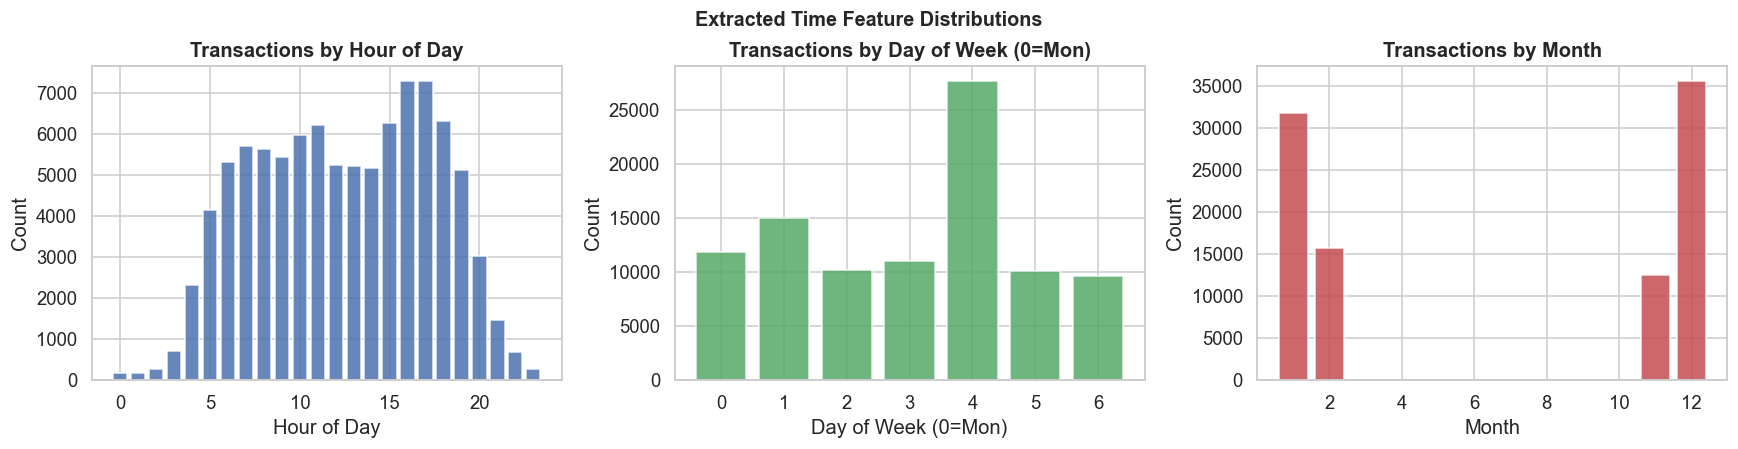

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
specs = [
    ("txn_hour",      "Hour of Day",          "#4C72B0"),
    ("txn_dayofweek", "Day of Week (0=Mon)",  "#55A868"),
    ("txn_month",     "Month",                "#C44E52"),
]
for ax, (col, label, color) in zip(axes, specs):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"Transactions by {label}", fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.suptitle("Extracted Time Feature Distributions", fontsize=13, fontweight="bold", y=1.02)
plt.savefig("../plots/feature_engineering/task3_time_features.png", bbox_inches="tight")
plt.show()


In [56]:
# Late-night flag: txn_hour between 23:00 and 04:00
late_night_pct = ((df["txn_hour"] >= 23) | (df["txn_hour"] <= 4)).mean() * 100
print(f"Late-night transactions (23:00–04:00): {late_night_pct:.1f}%")
print("These may represent a distinct risk segment worth capturing as a binary feature.")


Late-night transactions (23:00–04:00): 4.1%
These may represent a distinct risk segment worth capturing as a binary feature.


## 3. Customer-Level Aggregate Features

Collapse 95k+ transaction rows into **one row per customer** with 13 engineered features.

| Feature | Formula | Risk Signal |
|---------|---------|-------------|
| `total_amount` | Sum of all amounts | Overall spend level |
| `avg_amount` | Mean amount | Typical purchase size |
| `std_amount` | Std dev of amounts | Spend volatility |
| `max_amount` | Max single transaction | Highest-value exposure |
| `txn_count` | Count of transactions | Engagement depth |
| `debit_total` | Sum of positive amounts | Net purchasing behavior |
| `debit_avg` | Mean debit amount | Typical purchase value |
| `debit_ratio` | Debits / total txns | Balance of buying vs credits |
| `fraud_rate` | Fraud flags / total txns | Historical fraud exposure |
| `unique_products` | Count of distinct products | Breadth of purchases |
| `unique_channels` | Count of distinct channels | Multi-channel engagement |
| `unique_categories` | Count of distinct categories | Category diversity |


In [57]:
agg = build_aggregate_features(df)
print(f"Aggregate table: {agg.shape[0]:,} customers × {agg.shape[1]} columns")
agg.head(4)


2026-06-02 23:22:37,863 [INFO] src.data_processing — Building aggregate features per customer...
2026-06-02 23:22:38,071 [INFO] src.data_processing — Aggregate features built: 16 columns for 3,742 customers


Aggregate table: 3,742 customers × 16 columns


,CustomerId,total_amount,avg_amount,std_amount,max_amount,min_amount,txn_count,unique_products,unique_channels,unique_categories,fraud_count,debit_count,debit_total,debit_avg,fraud_rate,debit_ratio
0,CustomerId_1,-10000.0,-10000.000000,0.000000,-10000.0,-10000.0,1,1,1,1,0,0.0,0.0,0.0,0.0,0.000000
1,CustomerId_10,-10000.0,-10000.000000,0.000000,-10000.0,-10000.0,1,1,1,1,0,0.0,0.0,0.0,0.0,0.000000
2,CustomerId_1001,20000.0,4000.000000,6558.963333,10000.0,-5000.0,5,3,2,2,0,3.0,25200.0,8400.0,0.0,0.600000
3,CustomerId_1002,4225.0,384.090909,560.498966,1500.0,-75.0,11,3,2,2,0,5.0,4500.0,900.0,0.0,0.454545


In [58]:
agg.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T   .style.background_gradient(cmap="Blues", subset=["mean","50%","95%"])


,count,mean,std,min,5%,25%,50%,75%,95%,max
total_amount,3742.000000,171737.740647,2717304.824182,-104900000.000000,-10.000000,4077.437500,20000.000000,79967.750000,492756.830000,83451240.000000
avg_amount,3742.000000,15715.616012,167699.098433,-425000.000000,-2.500000,1000.000000,2583.846429,4877.613636,32837.677628,8601821.142857
std_amount,3742.000000,13605.166177,96893.437959,0.000000,0.000000,501.141058,3184.898145,6745.368782,28932.872380,3309916.123615
max_amount,3742.000000,50838.725815,359869.138134,-200000.000000,500.000000,2000.000000,10000.000000,18375.000000,100000.000000,9880000.000000
min_amount,3742.000000,3863.506026,85836.637712,-1000000.000000,-5000.000000,-5000.000000,-1000.000000,500.000000,10000.000000,2000000.000000
txn_count,3742.000000,25.564404,96.929602,1.000000,1.000000,2.000000,7.000000,20.000000,98.000000,4091.000000
unique_products,3742.000000,3.277392,2.042457,1.000000,1.000000,2.000000,3.000000,4.000000,7.000000,14.000000
unique_channels,3742.000000,1.757349,0.539207,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,4.000000
unique_categories,3742.000000,2.110636,0.962571,1.000000,1.000000,1.000000,2.000000,2.000000,4.000000,8.000000
fraud_count,3742.000000,0.051577,0.774328,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,31.000000


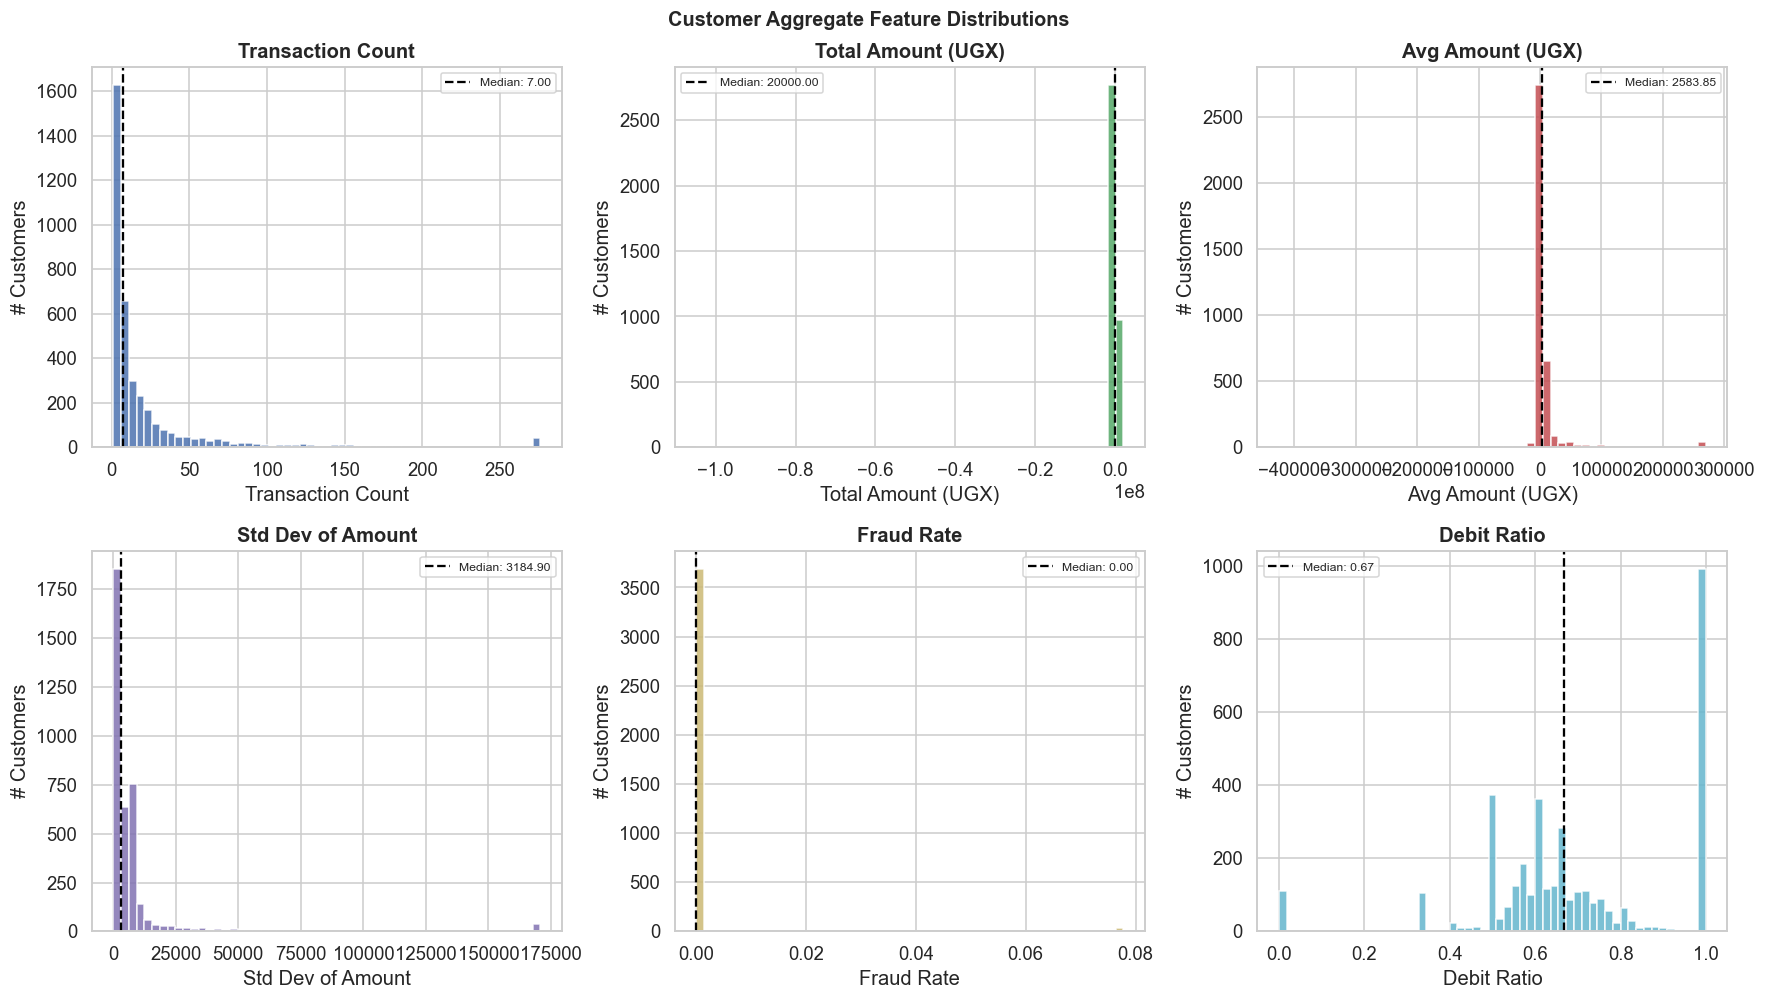

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_specs = [
    ("txn_count",    "Transaction Count",     "#4C72B0"),
    ("total_amount", "Total Amount (UGX)",    "#55A868"),
    ("avg_amount",   "Avg Amount (UGX)",      "#C44E52"),
    ("std_amount",   "Std Dev of Amount",     "#8172B2"),
    ("fraud_rate",   "Fraud Rate",            "#CCB974"),
    ("debit_ratio",  "Debit Ratio",           "#64B5CD"),
]
for ax, (col, label, color) in zip(axes.flat, plot_specs):
    data = agg[col].clip(upper=agg[col].quantile(0.99))
    ax.hist(data, bins=55, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("# Customers")
    ax.axvline(agg[col].median(), color="black", linestyle="--", linewidth=1.5,
               label=f"Median: {agg[col].median():.2f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle("Customer Aggregate Feature Distributions", fontsize=13, fontweight="bold", y=1.01)
plt.savefig("../plots/feature_engineering/task3_aggregate_features.png", bbox_inches="tight")
plt.show()


In [60]:
# Customers with high fraud rate deserve a closer look
high_fraud = agg[agg["fraud_rate"] > 0]
print(f"Customers with ≥1 fraudulent transaction : {len(high_fraud):,} ({len(high_fraud)/len(agg)*100:.1f}%)")
print(f"Their avg txn_count                      : {high_fraud['txn_count'].mean():.1f}")
print(f"Their avg fraud_rate                     : {high_fraud['fraud_rate'].mean():.4f}")


Customers with ≥1 fraudulent transaction : 54 (1.4%)
Their avg txn_count                      : 66.1
Their avg fraud_rate                     : 0.3850


## 4. RFM Feature Construction

The three RFM dimensions give us a compact, interpretable behavioural fingerprint
for each customer.

| Dimension | Definition | High-Risk Signal |
|-----------|-----------|-----------------|
| **Recency** | Days since last transaction | High (long inactivity = disengaged) |
| **Frequency** | Total transaction count | Low (infrequent = low commitment) |
| **Monetary** | Sum of **positive (debit)** amounts only | Low (low spend = limited financial capacity) |

> Note: Monetary sums debit amounts only (positive `Amount`).  
> Credits (refunds, cashback) are excluded to reflect genuine purchasing behaviour.


In [61]:
rfm = build_rfm_features(df)
print(f"RFM table: {rfm.shape[0]:,} customers × {rfm.shape[1]} columns")
rfm.head(5)


2026-06-02 23:22:43,570 [INFO] src.data_processing — Building RFM features. Snapshot date: 2019-02-14
2026-06-02 23:22:45,897 [INFO] src.data_processing — RFM table: 3,742 customers


RFM table: 3,742 customers × 4 columns


,CustomerId,Recency,Frequency,Monetary
0,CustomerId_1,84,1,0.0
1,CustomerId_10,84,1,0.0
2,CustomerId_1001,90,5,25200.0
3,CustomerId_1002,26,11,4500.0
4,CustomerId_1003,12,6,26000.0


In [62]:
rfm.describe(percentiles=[0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95]).T


,count,mean,std,min,5%,10%,25%,50%,75%,90%,95%,max
Recency,3742.0,31.461251,2.711893e+01,1.0,1.0,2.0,6.0,25.0,54.00,75.0,84.00,91.0
Frequency,3742.0,25.564404,9.692960e+01,1.0,1.0,1.0,2.0,7.0,20.00,57.9,98.00,4091.0
Monetary,3742.0,211864.440406,2.105998e+06,0.0,500.0,1000.0,5000.0,26000.0,89789.75,255540.0,534500.05,83466000.0


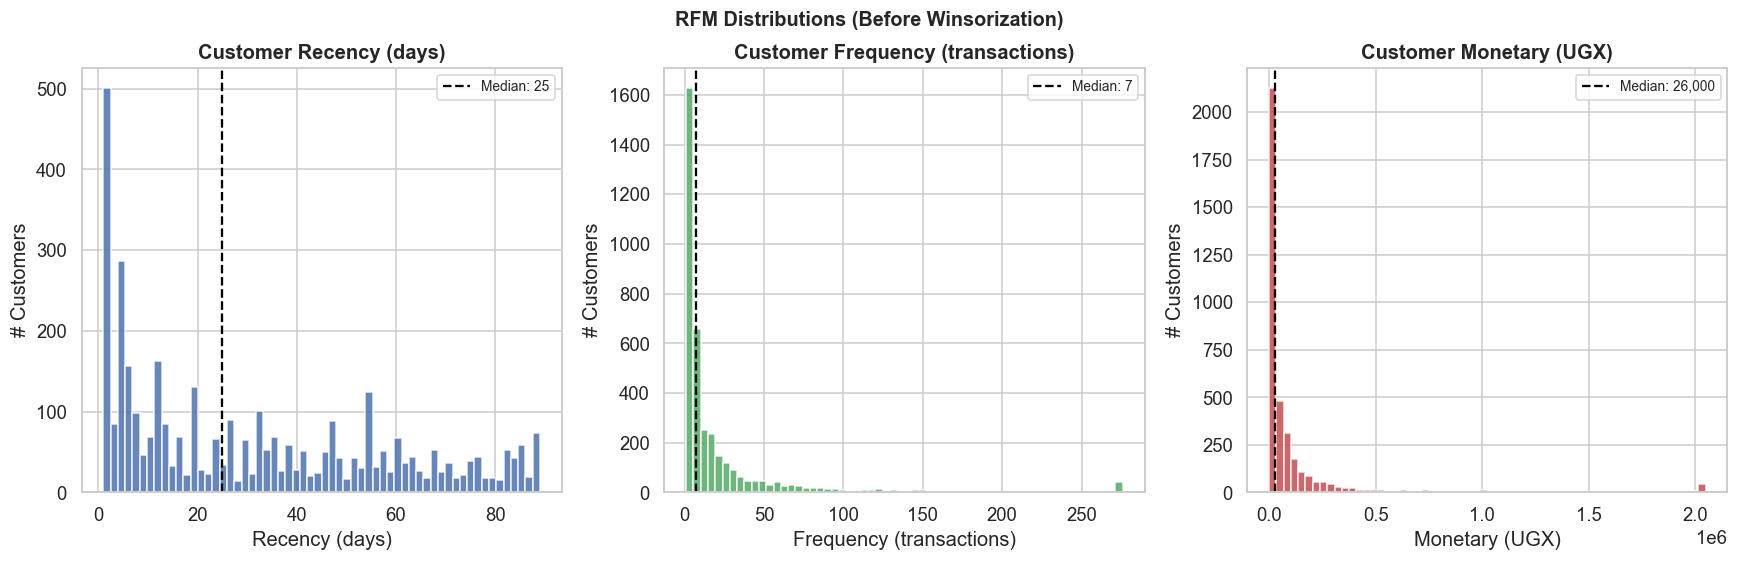

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
rfm_specs = [
    ("Recency",   "Recency (days)",          "#4C72B0"),
    ("Frequency", "Frequency (transactions)","#55A868"),
    ("Monetary",  "Monetary (UGX)",          "#C44E52"),
]
for ax, (col, label, color) in zip(axes, rfm_specs):
    data = rfm[col].clip(upper=rfm[col].quantile(0.99))
    ax.hist(data, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"Customer {label}", fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("# Customers")
    ax.axvline(rfm[col].median(), color="black", linestyle="--", linewidth=1.5,
               label=f"Median: {rfm[col].median():,.0f}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle("RFM Distributions (Before Winsorization)", fontsize=13, fontweight="bold", y=1.02)
plt.savefig("../plots/feature_engineering/task3_rfm_distributions.png", bbox_inches="tight")
plt.show()


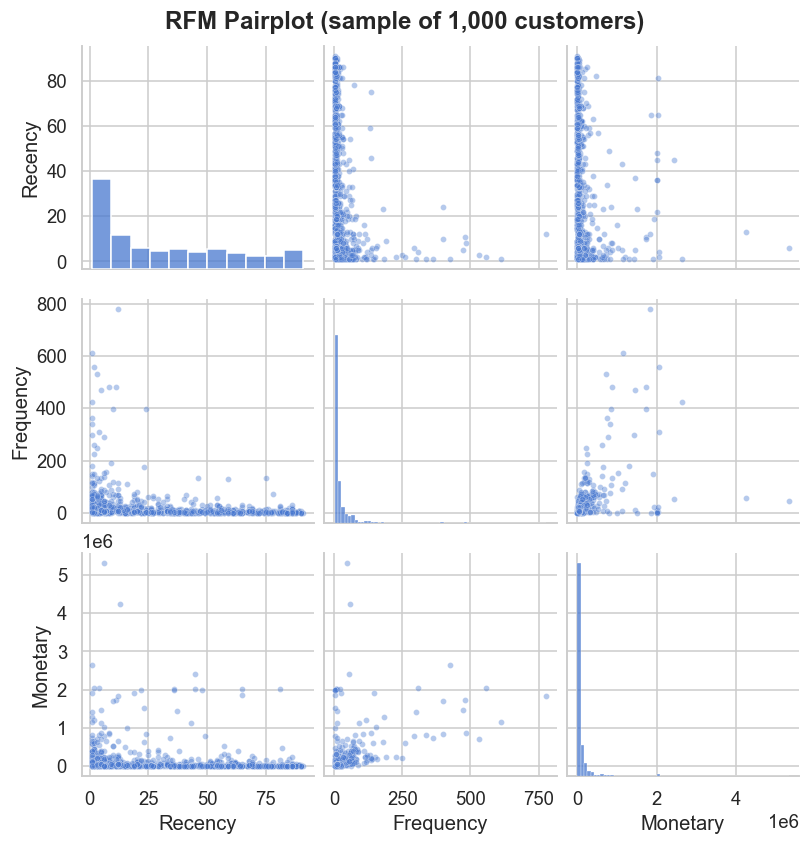

In [64]:
# Pairplot of raw RFM (sampled for speed)
sample = rfm.sample(min(1000, len(rfm)), random_state=SEED)
g = sns.pairplot(sample[["Recency","Frequency","Monetary"]], plot_kws={"alpha":0.4, "s":15},
                 diag_kind="hist")
g.fig.suptitle("RFM Pairplot (sample of 1,000 customers)", y=1.02, fontweight="bold")
plt.savefig("../plots/feature_engineering/task3_rfm_pairplot.png", bbox_inches="tight")
plt.show()


## 5. Outlier Treatment — Winsorization

**Why Winsorize?**
- K-Means is distance-based — a single 10M-UGX customer will distort cluster centroids
- Linear model coefficients are inflated by extreme values
- Removing rows would lose customers; capping preserves them with bounded values

**Basel II documentation requirement:**  
Capping boundaries must be logged and justified. We use 1st–99th percentile.


2026-06-02 23:22:53,006 [INFO] src.data_processing — Winsorized 'Monetary': [0.00, 2048375.42]
2026-06-02 23:22:53,017 [INFO] src.data_processing — Winsorized 'Frequency': [1.00, 275.95]


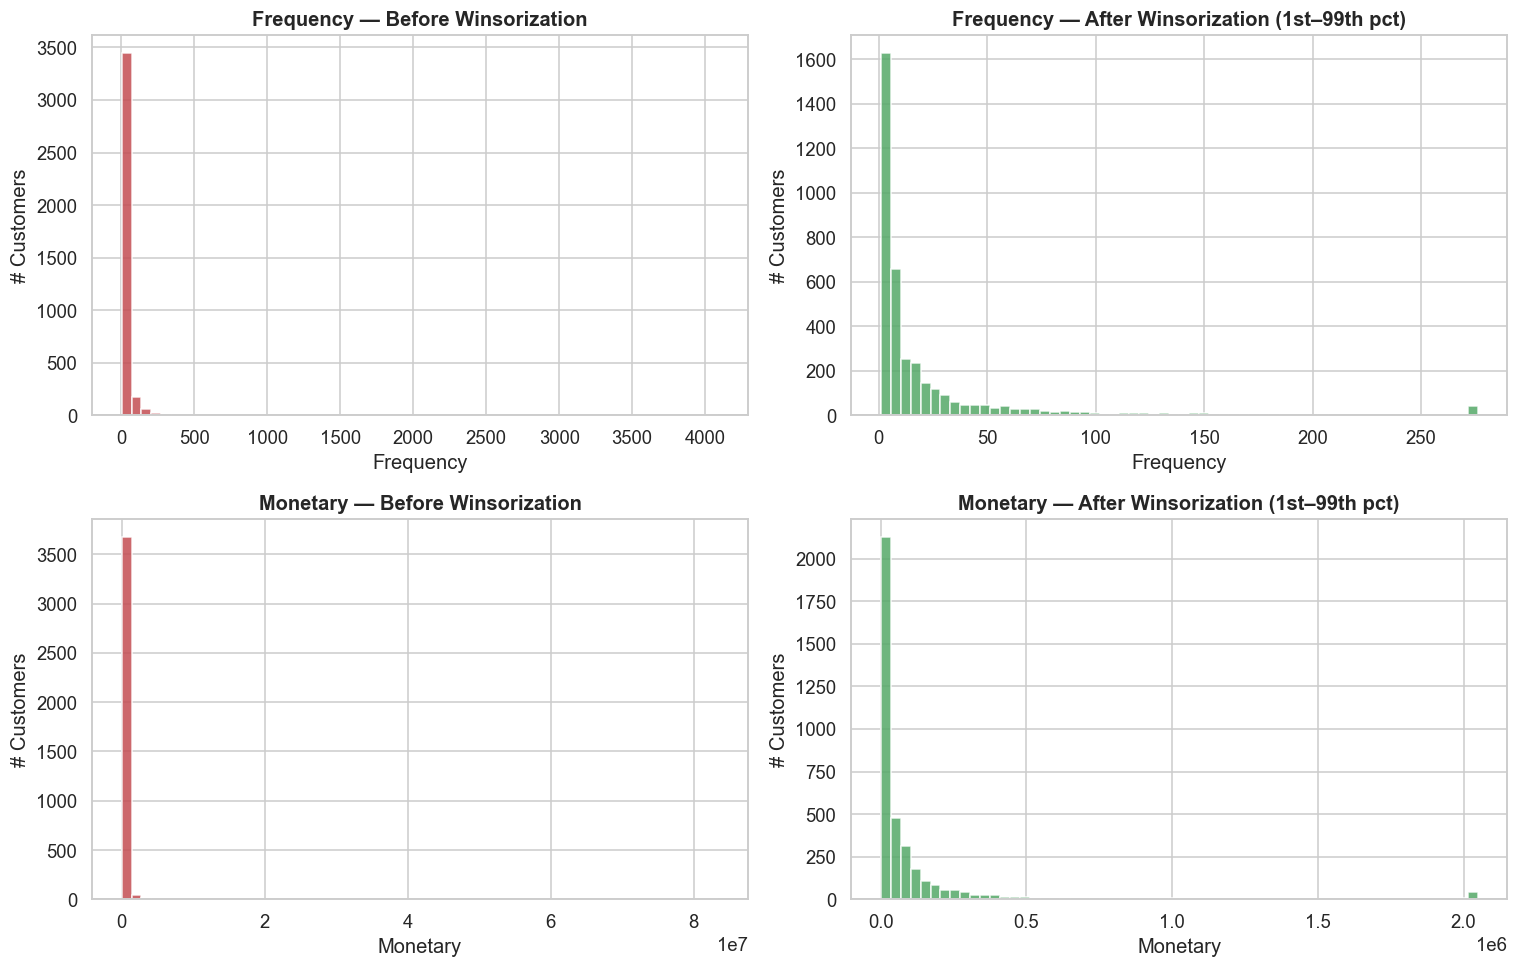

In [65]:
rfm_w = winsorize_features(rfm, cols=["Monetary","Frequency"], lower=0.01, upper=0.99)

# Before vs after — side by side
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for i, col in enumerate(["Frequency", "Monetary"]):
    for j, (data, title, color) in enumerate([
        (rfm[col],   f"{col} — Before Winsorization",              "#C44E52"),
        (rfm_w[col], f"{col} — After Winsorization (1st–99th pct)","#55A868"),
    ]):
        ax = axes[i][j]
        ax.hist(data, bins=60, color=color, edgecolor="white", alpha=0.85)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel(col)
        ax.set_ylabel("# Customers")

plt.tight_layout()
plt.savefig("../plots/feature_engineering/task3_winsorization.png", bbox_inches="tight")
plt.show()


In [66]:
for col in ["Frequency", "Monetary"]:
    print(f"{col}:")
    print(f"  Before  → min={rfm[col].min():>12,.0f}   max={rfm[col].max():>12,.0f}")
    print(f"  After   → min={rfm_w[col].min():>12,.0f}   max={rfm_w[col].max():>12,.0f}")
    print()


Frequency:
  Before  → min=           1   max=       4,091
  After   → min=           1   max=         276

Monetary:
  Before  → min=           0   max=  83,466,000
  After   → min=           0   max=   2,048,375



## 6. Categorical Encoding

Three approaches are available for credit scoring:

| Method | Pros | Cons | Used here? |
|--------|------|------|-----------|
| **Label Encoding** | Simple, low dimensionality | Implies ordinal relationship | ✅ Default |
| **One-Hot Encoding** | No ordinal assumption | High dimensionality with many categories | Optional |
| **Weight of Evidence (WoE)** | Risk-ordered, monotonic — ideal for Logistic Regression | Requires target variable | Task 5 |

We apply Label Encoding here. WoE encoding is deferred to the model training pipeline
where the target (`is_high_risk`) is available.


In [67]:
df_enc = encode_categorical_features(df)
encoded_cols = [c for c in df_enc.columns if c.endswith("_encoded")]
print("Label-encoded columns:", encoded_cols)


2026-06-02 23:22:57,415 [INFO] src.data_processing — Label-encoded 'ProductCategory' → 'ProductCategory_encoded'
2026-06-02 23:22:57,467 [INFO] src.data_processing — Label-encoded 'ChannelId' → 'ChannelId_encoded'
2026-06-02 23:22:57,503 [INFO] src.data_processing — Label-encoded 'ProviderId' → 'ProviderId_encoded'


Label-encoded columns: ['ProductCategory_encoded', 'ChannelId_encoded', 'ProviderId_encoded']


In [68]:
# Show mapping for ProductCategory
mapping = (df_enc[["ProductCategory","ProductCategory_encoded"]]
           .drop_duplicates()
           .sort_values("ProductCategory_encoded")
           .reset_index(drop=True))
print("ProductCategory encoding mapping:")
print(mapping.to_string(index=False))


ProductCategory encoding mapping:
   ProductCategory  ProductCategory_encoded
           airtime                        0
      data_bundles                        1
financial_services                        2
            movies                        3
             other                        4
            ticket                        5
         transport                        6
                tv                        7
      utility_bill                        8


2026-06-02 23:22:58,164 [INFO] matplotlib.category — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-02 23:22:58,167 [INFO] matplotlib.category — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-02 23:22:58,186 [INFO] matplotlib.category — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-02 23:22:58,189 [INFO] matplotlib.category — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-02 23:22:58,200 [INF

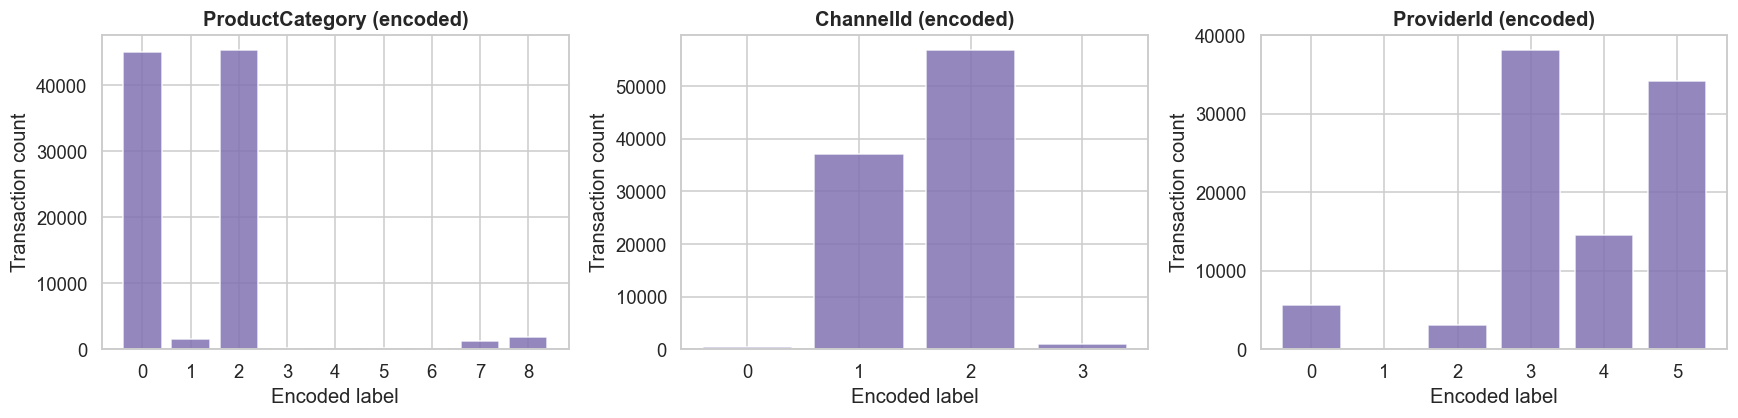

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["ProductCategory_encoded","ChannelId_encoded","ProviderId_encoded"]):
    if col not in df_enc.columns:
        ax.set_visible(False)
        continue
    vc = df_enc[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color="#8172B2", edgecolor="white", alpha=0.85)
    ax.set_title(col.replace("_encoded","") + " (encoded)", fontweight="bold")
    ax.set_xlabel("Encoded label")
    ax.set_ylabel("Transaction count")

plt.tight_layout()
plt.savefig("../plots/feature_engineering/task3_categorical_encoding.png", bbox_inches="tight")
plt.show()


## 7. sklearn Preprocessing Pipeline

Chain **median imputation → StandardScaler** into a single sklearn `Pipeline`.

Key principles:
- `fit()` only on training data — never on test data or the full dataset
- `transform()` applied to both train and test to prevent data leakage
- Pipeline object is serialisable — can be saved with the model and applied at inference


In [70]:
pipeline = get_preprocessing_pipeline()
print(pipeline)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [71]:
numeric_cols = ["total_amount","avg_amount","std_amount","txn_count","fraud_rate","debit_ratio"]
numeric_cols = [c for c in numeric_cols if c in agg.columns]

scaled_arr = pipeline.fit_transform(agg[numeric_cols])
scaled_df  = pd.DataFrame(scaled_arr, columns=[c + "_scaled" for c in numeric_cols])

print(f"Input  shape: {agg[numeric_cols].shape}")
print(f"Output shape: {scaled_df.shape}")
print()
print("Post-scaling means (should be ≈ 0):")
print(scaled_df.mean().round(6).to_string())
print()
print("Post-scaling stds  (should be ≈ 1):")
print(scaled_df.std().round(3).to_string())


Input  shape: (3742, 6)
Output shape: (3742, 6)

Post-scaling means (should be ≈ 0):
total_amount_scaled   -0.0
avg_amount_scaled      0.0
std_amount_scaled      0.0
txn_count_scaled      -0.0
fraud_rate_scaled      0.0
debit_ratio_scaled    -0.0

Post-scaling stds  (should be ≈ 1):
total_amount_scaled    1.0
avg_amount_scaled      1.0
std_amount_scaled      1.0
txn_count_scaled       1.0
fraud_rate_scaled      1.0
debit_ratio_scaled     1.0


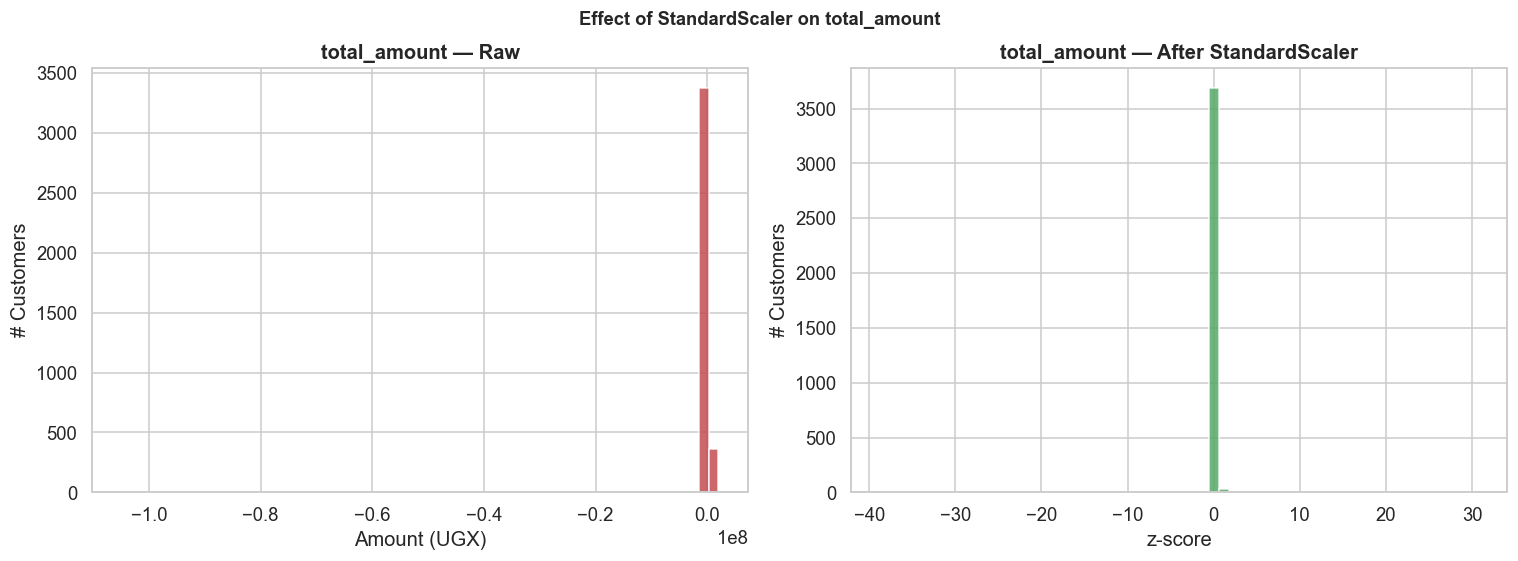

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(agg["total_amount"].clip(upper=agg["total_amount"].quantile(0.99)),
             bins=60, color="#C44E52", edgecolor="white", alpha=0.85)
axes[0].set_title("total_amount — Raw", fontweight="bold")
axes[0].set_xlabel("Amount (UGX)")
axes[0].set_ylabel("# Customers")

axes[1].hist(scaled_df["total_amount_scaled"], bins=60,
             color="#55A868", edgecolor="white", alpha=0.85)
axes[1].set_title("total_amount — After StandardScaler", fontweight="bold")
axes[1].set_xlabel("z-score")
axes[1].set_ylabel("# Customers")

plt.tight_layout()
plt.suptitle("Effect of StandardScaler on total_amount", fontsize=12, fontweight="bold", y=1.02)
plt.savefig("../plots/feature_engineering/task3_scaling_effect.png", bbox_inches="tight")
plt.show()


## 8. Final Merged Dataset Inspection

Merge RFM (winsorized) + aggregate features into a single customer-level DataFrame.
This is the input that Task 4 will add the proxy target column to.


In [73]:
feature_df = rfm_w.merge(agg, on="CustomerId", how="left")
feature_df = pd.concat([feature_df, scaled_df], axis=1)
print(f"Feature dataset: {feature_df.shape[0]:,} customers × {feature_df.shape[1]} columns")
print()
print("Null counts:")
nulls = feature_df.isna().sum()
print(nulls[nulls > 0].to_string() if nulls.any() else "  None — clean dataset ✅")
feature_df.head(4)


Feature dataset: 3,742 customers × 25 columns

Null counts:
  None — clean dataset ✅


,CustomerId,Recency,Frequency,Monetary,total_amount,avg_amount,std_amount,max_amount,min_amount,txn_count,...,debit_total,debit_avg,fraud_rate,debit_ratio,total_amount_scaled,avg_amount_scaled,std_amount_scaled,txn_count_scaled,fraud_rate_scaled,debit_ratio_scaled
0,CustomerId_1,84,1.0,0.0,-10000.0,-10000.000000,0.000000,-10000.0,-10000.0,1,...,0.0,0.0,0.0,0.000000,-0.066891,-0.153364,-0.140432,-0.253459,-0.086096,-3.038494
1,CustomerId_10,84,1.0,0.0,-10000.0,-10000.000000,0.000000,-10000.0,-10000.0,1,...,0.0,0.0,0.0,0.000000,-0.066891,-0.153364,-0.140432,-0.253459,-0.086096,-3.038494
2,CustomerId_1001,90,5.0,25200.0,20000.0,4000.000000,6558.963333,10000.0,-5000.0,5,...,25200.0,8400.0,0.0,0.600000,-0.055849,-0.069870,-0.072731,-0.212186,-0.086096,-0.422898
3,CustomerId_1002,26,11.0,4500.0,4225.0,384.090909,560.498966,1500.0,-75.0,11,...,4500.0,900.0,0.0,0.454545,-0.061655,-0.091435,-0.134647,-0.150278,-0.086096,-1.056982


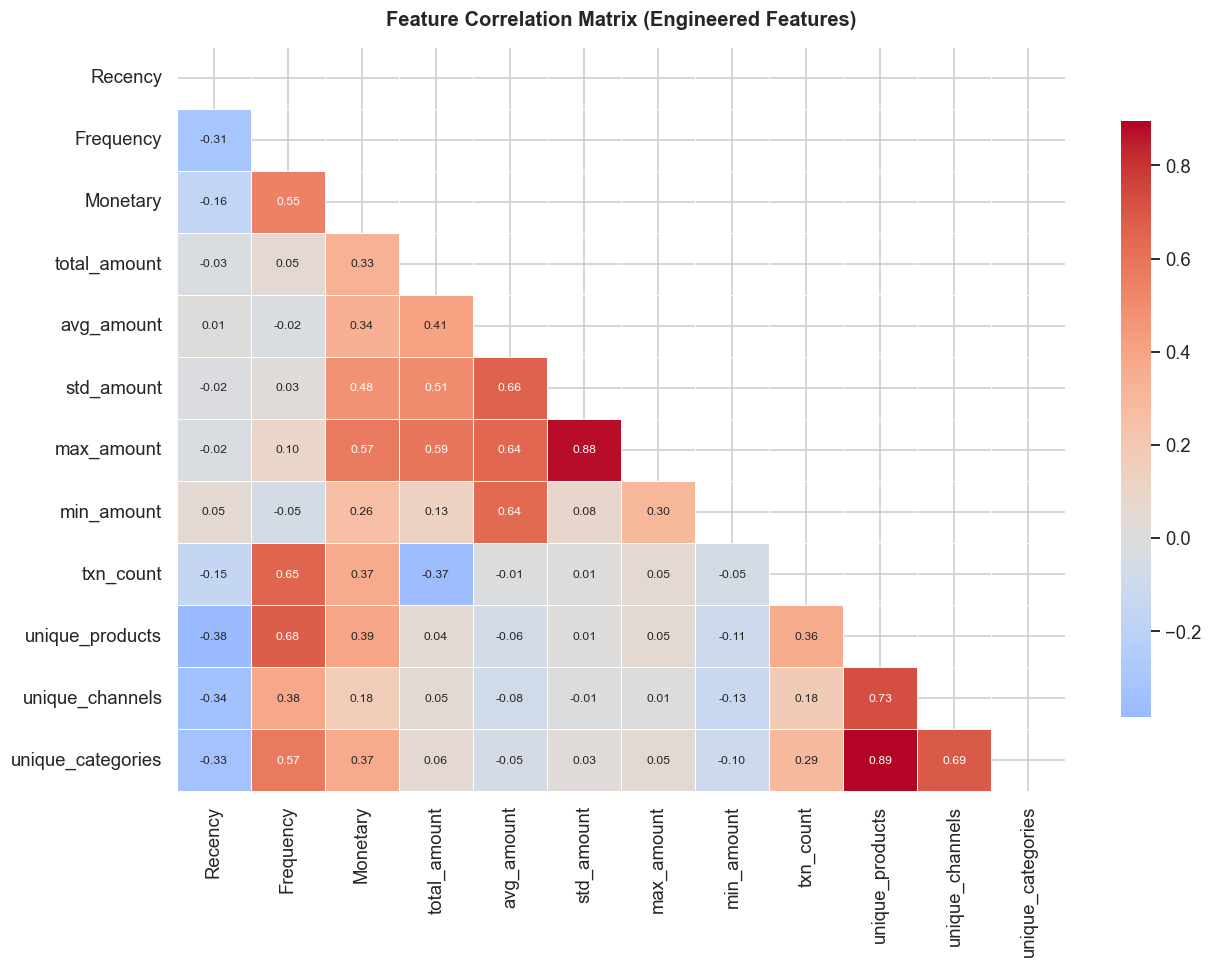

In [74]:
# Correlation heatmap of engineered features
num_cols = feature_df.select_dtypes(include="number").columns.tolist()
# Exclude scaled duplicates for clarity
plot_cols = [c for c in num_cols if not c.endswith("_scaled")][:12]

fig, ax = plt.subplots(figsize=(12, 9))
corr = feature_df[plot_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5, cbar_kws={"shrink":0.8},
            annot_kws={"size": 8})
ax.set_title("Feature Correlation Matrix (Engineered Features)", fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig("../plots/feature_engineering/task3_feature_correlation.png", bbox_inches="tight")
plt.show()


In [75]:
# Save feature dataset for Task 4
import os
os.makedirs("../data/processed", exist_ok=True)
feature_df.to_csv("../data/processed/features_task3.csv", index=False)
print("✅ Feature dataset saved → data/processed/features_task3.csv")
print(f"   Shape: {feature_df.shape}")


✅ Feature dataset saved → data/processed/features_task3.csv
   Shape: (3742, 25)


## Task 3 Summary

| Step | Output columns | Key decision |
|------|---------------|-------------|
| Time extraction | `txn_hour`, `txn_day`, `txn_month`, `txn_year`, `txn_dayofweek` | Decomposed from `TransactionStartTime` |
| Aggregate features | 13 customer-level columns | Fraud rate, debit ratio, spend variability |
| RFM | `Recency`, `Frequency`, `Monetary` | Debit-only Monetary; snapshot = max date + 1 day |
| Winsorization | Clipped `Monetary` & `Frequency` | 1st–99th percentile; boundaries logged for Basel II |
| Categorical encoding | `*_encoded` columns | Label encoding; WoE deferred to model pipeline |
| Scaling pipeline | `*_scaled` columns | Imputer → StandardScaler; fitted on train only |


